# Per-County Transformer for Power Outage Forecasting (24h & 48h Sequences)

Each county gets its own lightweight Transformer trained on historical weather + outage data.
The model predicts the **next 48 hours** of hourly outage counts as a sequence.

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.notebook import tqdm
import warnings, time
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [59]:
# ── Data & Window ──
WINDOW_SIZE = 24       # hours of history as input
HORIZON_24 = 24        # predict next 24 hours
HORIZON_48 = 48        # predict next 48 hours
TRAIN_RATIO = 0.8

# ── Model Architecture ──
D_MODEL = 64
NHEAD = 4
NUM_LAYERS = 2
DIM_FF = 128
DROPOUT = 0.15

# ── Training ──
BATCH_SIZE = 16
EPOCHS = 50
LR = 5e-4
WEIGHT_DECAY = 1e-3
PATIENCE = 15

# ── Scheduler ──
SCHEDULER = 'CosineAnnealingLR'
STEP_SIZE = 10
GAMMA = 0.5

# ── Columns to drop (non-feature) ──
DROP_COLS = ['location', 'timestamp', 'out', 'tracked',
             'state_x', 'state_y', 'state_y.1', 'state_y.2', 'state_y.3']

## 1. Load All Counties

In [60]:
xlsx = pd.ExcelFile('cleaned_output.xlsx')
county_names = xlsx.sheet_names
print(f"Total counties: {len(county_names)}")
print(f"Counties: {county_names[:10]} ...")

# Load all sheets into a dict
county_data = {}
for name in county_names:
    df = pd.read_excel(xlsx, sheet_name=name)
    df.columns = [str(c).strip() for c in df.columns]
    df = df.sort_values('timestamp').reset_index(drop=True)
    county_data[name] = df

# Show sample
sample = county_data[county_names[0]]
print(f"\nSample county {county_names[0]}: {sample.shape}")
print(f"Time range: {sample['timestamp'].min()} → {sample['timestamp'].max()}")

Total counties: 83
Counties: ['26001', '26003', '26005', '26007', '26009', '26011', '26013', '26015', '26017', '26019'] ...

Sample county 26001: (2161, 87)
Time range: 2023-04-01 00:00:00 → 2023-06-30 00:00:00


## 2. Dataset Class

In [61]:
class OutageDataset(Dataset):
    """Sliding-window dataset: predict the next 48 hours of outage counts."""
    def __init__(self, features, targets, window=48, horizon=48):
        self.features = features
        self.targets = targets
        self.window = window
        self.horizon = horizon
        self.valid_indices = list(range(window, len(targets) - horizon))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t = self.valid_indices[idx]
        x = self.features[t - self.window : t]       # (window, n_feat)
        y = self.targets[t : t + self.horizon]        # (horizon,) — next 48h
        return torch.FloatTensor(x), torch.FloatTensor(y)

## 3. Transformer Model

In [62]:
class TemporalTransformer(nn.Module):
    """
    Transformer encoder for seq-to-seq outage forecasting.
    Uses all encoder outputs (pooled) instead of only the last timestep,
    giving the prediction head richer information to produce varied outputs.
    """
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2,
                 dim_ff=128, dropout=0.1, window=48, horizon=48):
        super().__init__()
        self.window = window
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, window, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        # Use all window timesteps: flatten encoder output → predict horizon
        self.head = nn.Sequential(
            nn.Linear(window * d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, horizon)
        )

    def forward(self, x):
        b = x.size(0)
        x = self.input_proj(x) + self.pos_embedding
        x = self.norm(self.transformer(x))   # (batch, window, d_model)
        x = x.reshape(b, -1)                  # (batch, window * d_model)
        return self.head(x)                    # (batch, horizon)

## 4. Data Preprocessing & Training Functions

In [63]:
def prepare_county(df):
    """Prepare features and targets for one county."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feat_cols = [c for c in numeric_cols if c not in DROP_COLS]
    features = df[feat_cols].copy().ffill().bfill().fillna(0).values.astype(np.float32)

    hour = df['timestamp'].dt.hour.values
    hour_sin = np.sin(2 * np.pi * hour / 24).reshape(-1, 1).astype(np.float32)
    hour_cos = np.cos(2 * np.pi * hour / 24).reshape(-1, 1).astype(np.float32)
    dow = df['timestamp'].dt.dayofweek.values
    dow_sin = np.sin(2 * np.pi * dow / 7).reshape(-1, 1).astype(np.float32)
    dow_cos = np.cos(2 * np.pi * dow / 7).reshape(-1, 1).astype(np.float32)
    features = np.hstack([features, hour_sin, hour_cos, dow_sin, dow_cos])

    targets = df['log_out'].values.astype(np.float32)

    split = int(len(df) * TRAIN_RATIO)

    feat_scaler = StandardScaler()
    features[:split] = feat_scaler.fit_transform(features[:split])
    features[split:] = feat_scaler.transform(features[split:])

    from sklearn.preprocessing import MinMaxScaler
    target_scaler = MinMaxScaler()
    targets[:split] = target_scaler.fit_transform(targets[:split].reshape(-1, 1)).flatten()
    targets[split:] = target_scaler.transform(targets[split:].reshape(-1, 1)).flatten()

    return features, targets, split, target_scaler


def train_county_model(county_name, df, verbose=False):
    """Train a Transformer for one county. Predicts next 48 hours."""
    features, targets, split, target_scaler = prepare_county(df)
    n_feat = features.shape[1]

    train_ds = OutageDataset(features[:split], targets[:split],
                             window=WINDOW_SIZE, horizon=HORIZON_48)
    val_ds   = OutageDataset(features[split - WINDOW_SIZE:], targets[split - WINDOW_SIZE:],
                             window=WINDOW_SIZE, horizon=HORIZON_48)

    if len(train_ds) < 10 or len(val_ds) < 5:
        if verbose:
            print(f"  {county_name}: not enough data (train={len(train_ds)}, val={len(val_ds)}), skipping")
        return None

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = TemporalTransformer(
        n_features=n_feat, d_model=D_MODEL, nhead=NHEAD,
        num_layers=NUM_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT,
        window=WINDOW_SIZE, horizon=HORIZON_48
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    if SCHEDULER == 'CosineAnnealingLR':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    else:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        epoch_train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * len(x_batch)
        epoch_train_loss /= len(train_ds)
        train_losses.append(epoch_train_loss)
        scheduler.step()

        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                pred = model(x_batch)
                epoch_val_loss += criterion(pred, y_batch).item() * len(x_batch)
        epoch_val_loss /= len(val_ds)
        val_losses.append(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            pred = model(x_batch)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y_batch.numpy())

    preds_scaled = np.concatenate(all_preds)
    actuals_scaled = np.concatenate(all_targets)

    preds_log = target_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(preds_scaled.shape)
    actuals_log = target_scaler.inverse_transform(actuals_scaled.reshape(-1, 1)).reshape(actuals_scaled.shape)

    p1, a1 = preds_log[:, 0], actuals_log[:, 0]
    metrics = {
        'MSE': mean_squared_error(a1, p1),
        'RMSE': np.sqrt(mean_squared_error(a1, p1)),
        'MAE': mean_absolute_error(a1, p1),
        'R2': r2_score(a1, p1) if np.std(a1) > 0 else float('nan'),
    }

    return {
        'metrics': metrics,
        'preds_log': preds_log.astype(np.float32),
        'actuals_log': actuals_log.astype(np.float32),
        'preds': np.expm1(np.clip(preds_log, 0, 20)).astype(np.float32),
        'actuals': np.expm1(actuals_log).astype(np.float32),
        'model': model,
        'target_scaler': target_scaler,
        'train_losses': train_losses,
        'val_losses': val_losses,
    }

## 5. Train All Counties

Counties:   0%|          | 0/83 [00:00<?, ?it/s]

[ 1/83] 26001 | MSE=0.6396  MAE=0.2822  R²=-0.090
[ 2/83] 26003 | MSE=0.2220  MAE=0.3085  R²=-9.830
[ 3/83] 26005 | MSE=1.8672  MAE=0.8319  R²=-0.020
[ 4/83] 26007 | MSE=0.0000  MAE=0.0054  R²=nan
[ 5/83] 26009 | MSE=1.1507  MAE=0.3507  R²=-0.046
[ 6/83] 26011 | MSE=3.8662  MAE=0.7537  R²=-0.033
[ 7/83] 26013 | MSE=0.5318  MAE=0.4268  R²=-2.395
[ 8/83] 26015 | MSE=3.0764  MAE=0.8373  R²=-0.107
[ 9/83] 26017 | MSE=2.3757  MAE=0.6903  R²=-0.085
[10/83] 26019 | MSE=0.6673  MAE=0.5401  R²=-0.272
[11/83] 26021 | MSE=4.5872  MAE=1.5558  R²=0.013
[12/83] 26023 | MSE=0.9134  MAE=0.5355  R²=-0.192
[13/83] 26025 | MSE=3.4287  MAE=1.1194  R²=-0.158
[14/83] 26027 | MSE=1.8478  MAE=0.9321  R²=0.119
[15/83] 26029 | MSE=0.4328  MAE=0.2899  R²=-0.075
[16/83] 26031 | MSE=0.2980  MAE=0.2185  R²=-0.076
[17/83] 26033 | MSE=0.5662  MAE=0.1930  R²=-0.008
[18/83] 26035 | MSE=1.1262  MAE=0.4185  R²=0.023
[19/83] 26037 | MSE=1.4803  MAE=0.7784  R²=-0.106
[20/83] 26039 | MSE=0.8753  MAE=0.5823  R²=-0.650
[21/83

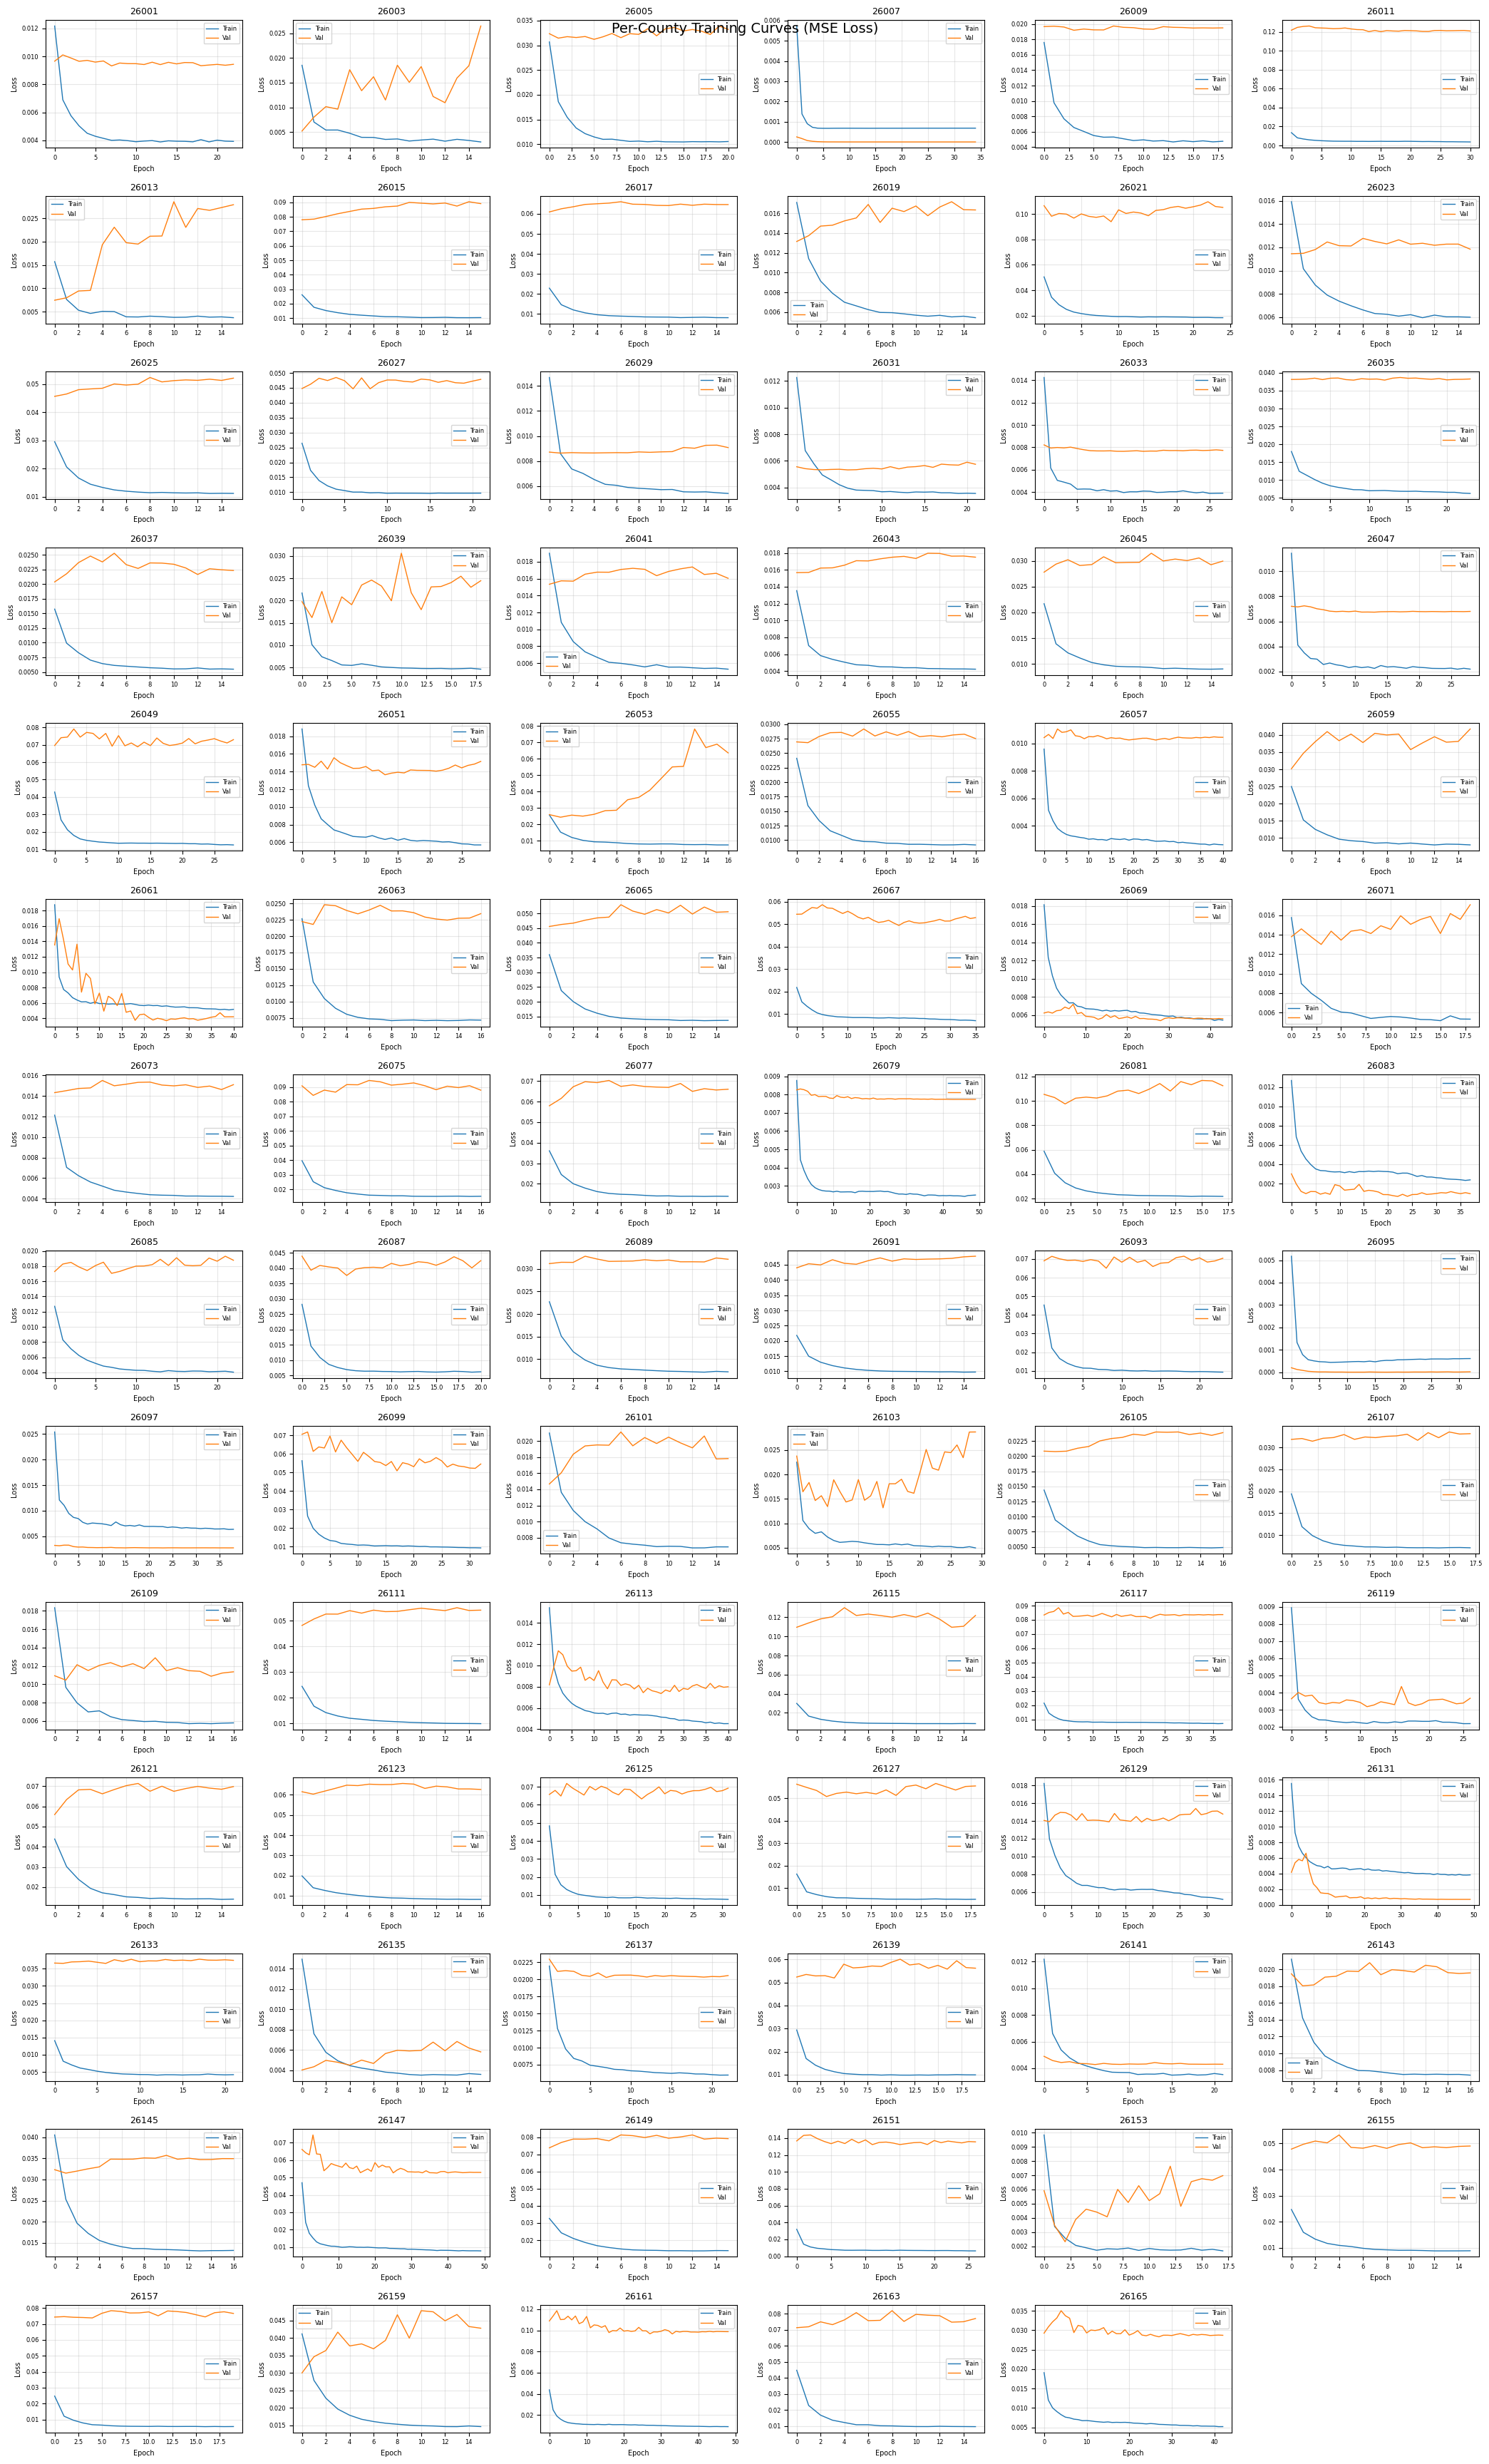

In [64]:
all_results = {}
t0 = time.time()

for i, county in enumerate(tqdm(county_names, desc='Counties')):
    df = county_data[county]
    result = train_county_model(county, df, verbose=True)
    if result is not None:
        all_results[county] = result
        m = result['metrics']
        tqdm.write(f"[{i+1:2d}/{len(county_names)}] {county} | "
                   f"MSE={m['MSE']:.4f}  MAE={m['MAE']:.4f}  R\u00b2={m['R2']:.3f}")
    else:
        tqdm.write(f"[{i+1:2d}/{len(county_names)}] {county} | SKIPPED")

elapsed = time.time() - t0
print(f"\nDone: {len(all_results)}/{len(county_names)} counties trained in {elapsed/60:.1f} min")

# Plot train/val loss curves for all counties
n_counties = len(all_results)
n_cols = 6
n_rows = (n_counties + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 2.5 * n_rows))
axes = axes.flatten()

for idx, (county, res) in enumerate(sorted(all_results.items())):
    ax = axes[idx]
    ax.plot(res['train_losses'], label='Train', linewidth=1)
    ax.plot(res['val_losses'], label='Val', linewidth=1)
    ax.set_title(county, fontsize=9)
    ax.set_xlabel('Epoch', fontsize=7)
    ax.set_ylabel('Loss', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_counties, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Per-County Training Curves (MSE Loss)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Summary Table

In [65]:
# Build per-county metrics table (1h single-step, comparable to LSTM)
rows = []
for county, res in all_results.items():
    m = res['metrics']
    rows.append({'County': county, 'MSE': m['MSE'], 'RMSE': m['RMSE'],
                 'MAE': m['MAE'], 'R2': m['R2']})

summary_df = pd.DataFrame(rows).set_index('County')

print("=== Per-County Validation Metrics (1h single-step) ===")
display(summary_df.round(4))

print(f"\n=== Average Across Counties ===")
print(f"MSE:  {summary_df['MSE'].mean():.4f}")
print(f"MAE:  {summary_df['MAE'].mean():.4f}")
print(f"R\u00b2:   {summary_df['R2'].mean():.4f}")

=== Per-County Validation Metrics (1h single-step) ===


,MSE,RMSE,MAE,R2
County,,,,
26001,0.6396,0.7998,0.2822,-0.0903
26003,0.2220,0.4712,0.3085,-9.8304
26005,1.8672,1.3664,0.8319,-0.0204
26007,0.0000,0.0054,0.0054,NaN
26009,1.1507,1.0727,0.3507,-0.0461
...,...,...,...,...
26157,1.5840,1.2586,0.7893,0.4392
26159,1.6371,1.2795,0.9576,-0.4702
26161,4.6380,2.1536,1.7455,0.3969



=== Average Across Counties ===
MSE:  1.6077
MAE:  0.6839
R²:   -0.6110


## 7. Visualization — Actual vs Prediction on Validation Set

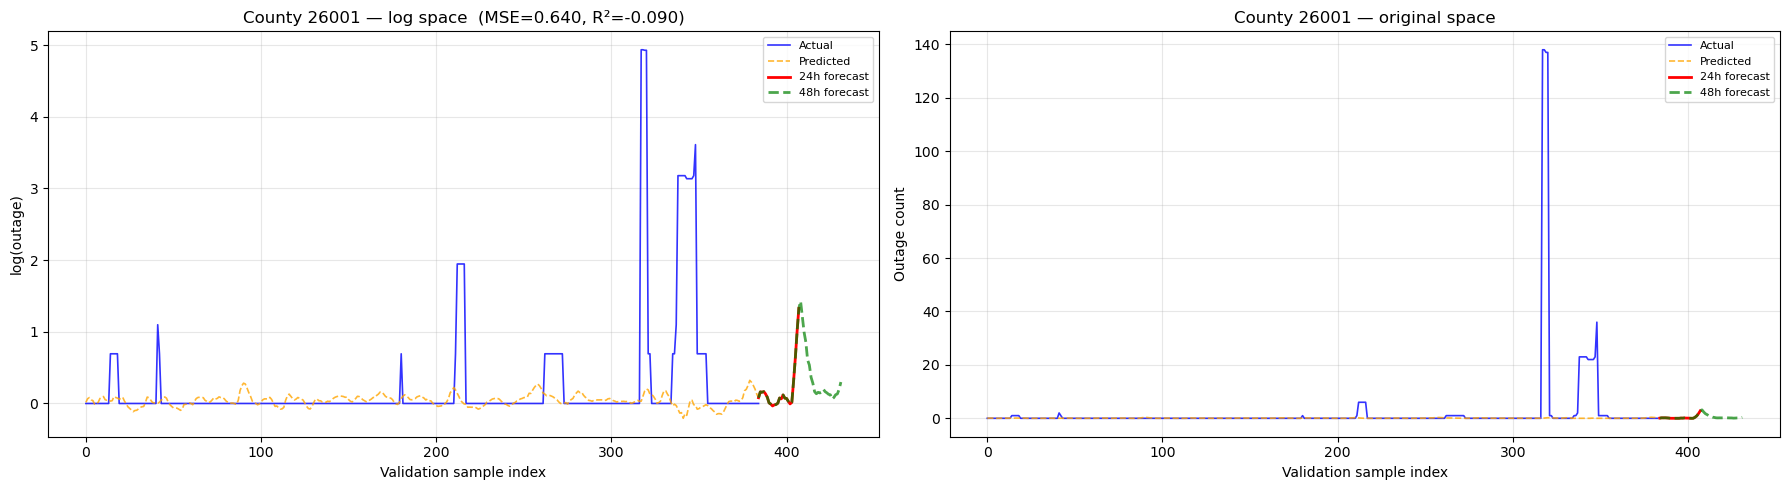

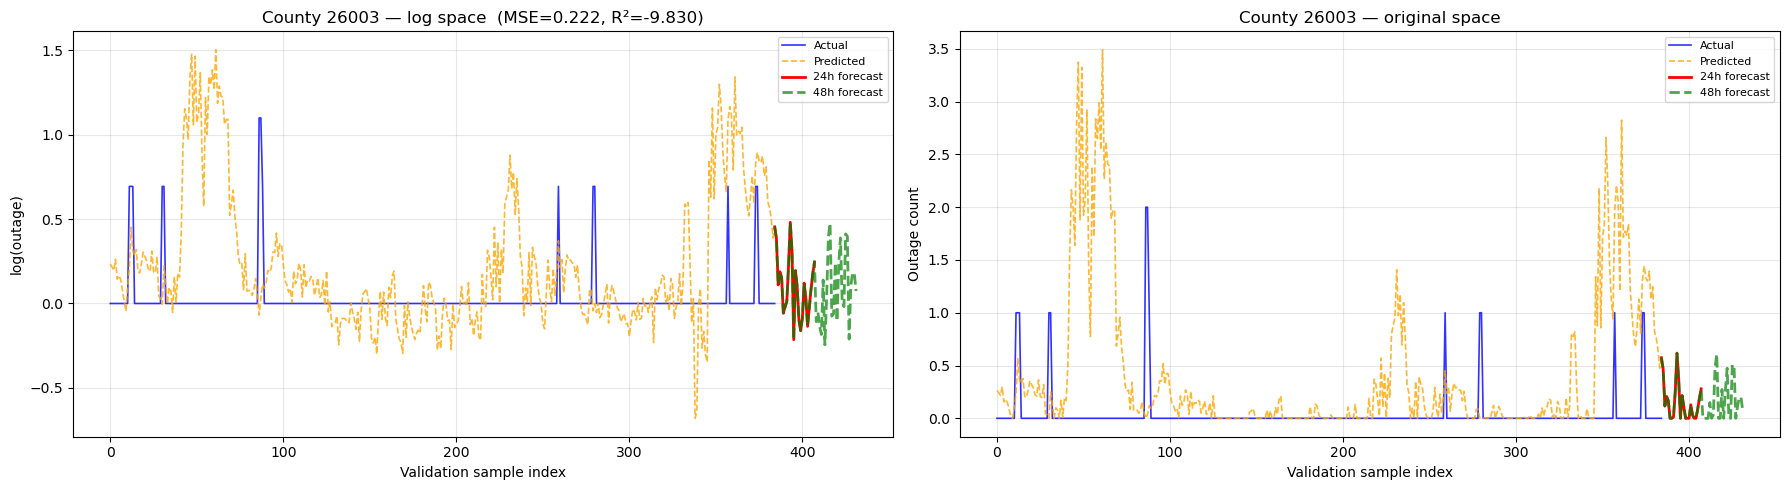

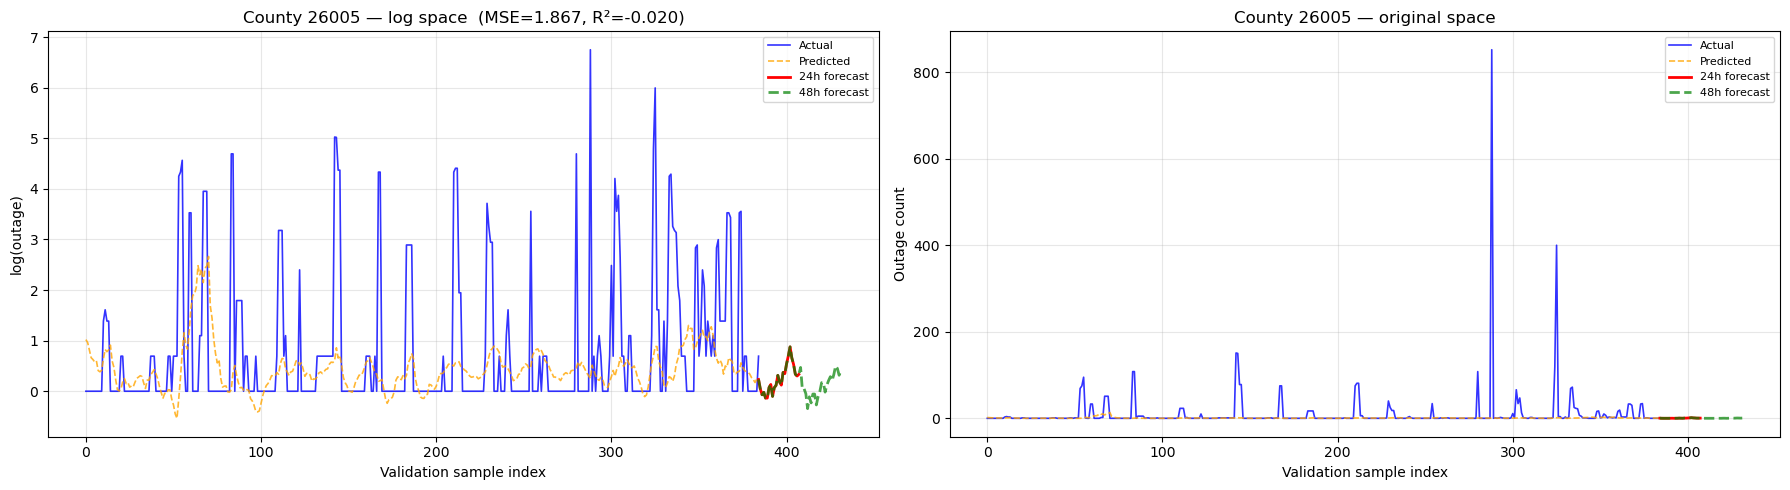

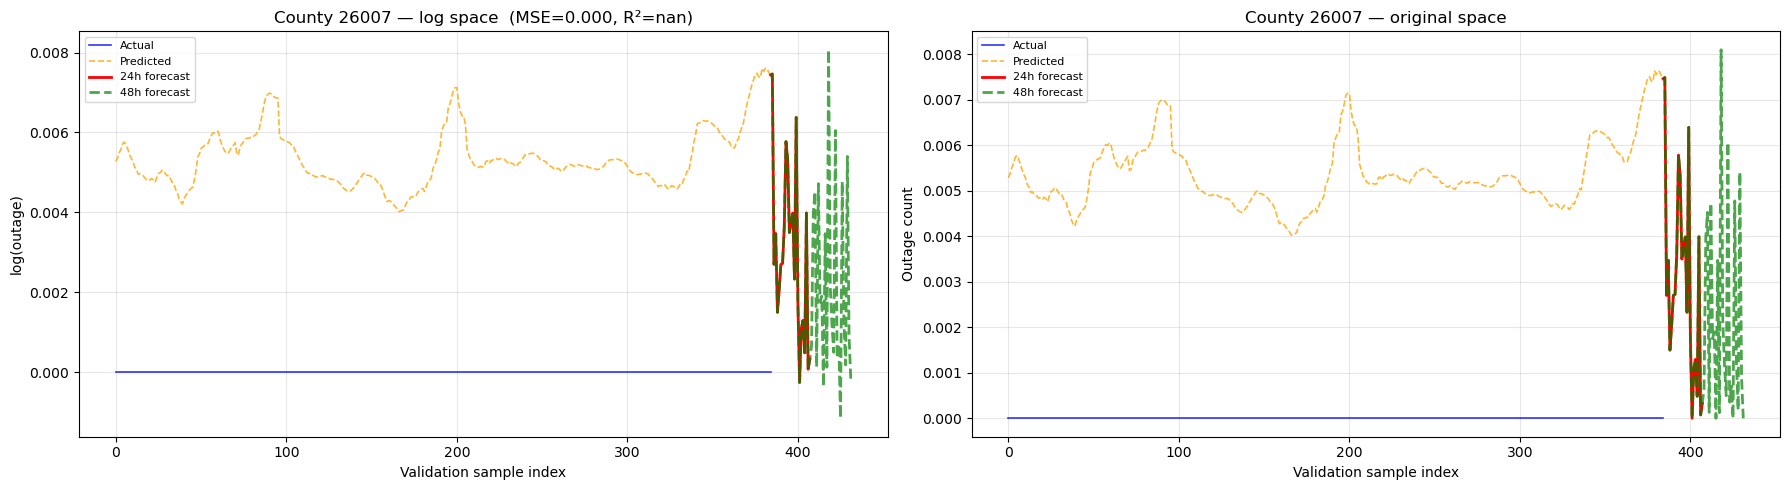

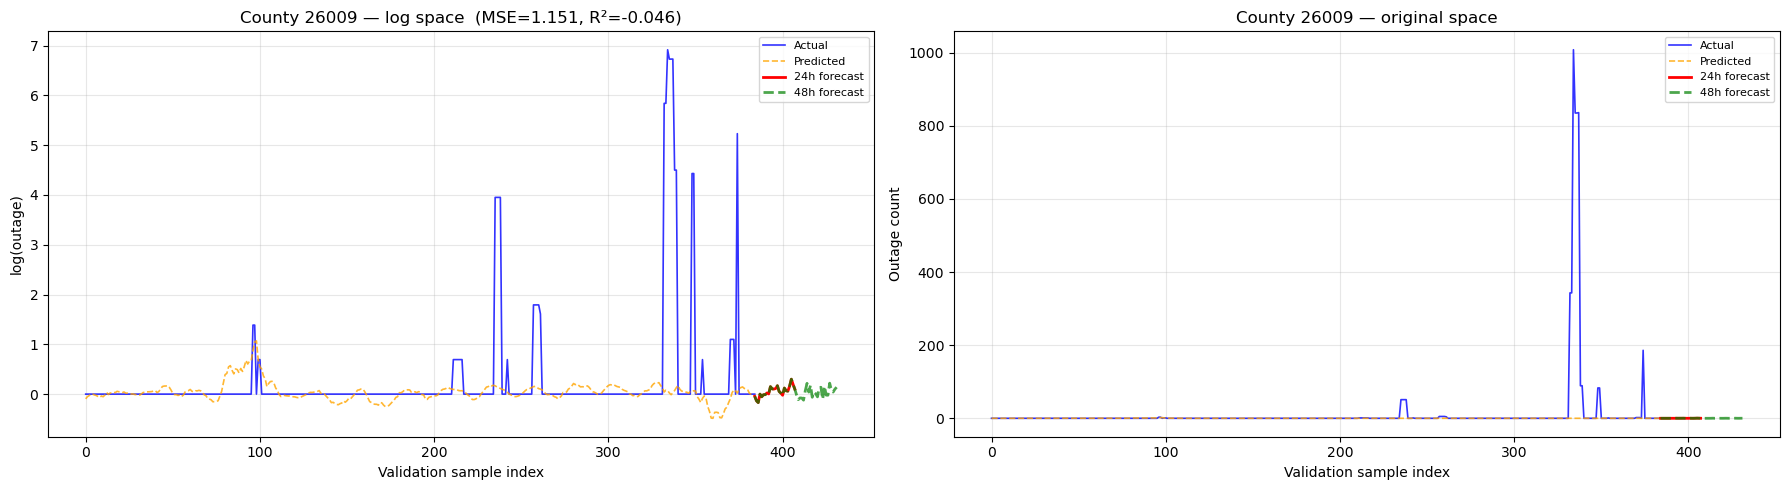

In [69]:
# Visualization for first 5 counties (by FIPS number)
top5 = sorted(all_results.keys())[:5]

for county in top5:
    res = all_results[county]
    m = res['metrics']
    n_val = res['preds_log'].shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Left: log space
    ax = axes[0]
    ax.plot(res['actuals_log'][:, 0], color='blue', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(res['preds_log'][:, 0], color='orange', linewidth=1.2, linestyle='--', label='Predicted', alpha=0.8)
    last_idx = n_val - 1
    ax.plot(range(last_idx, last_idx + 24), res['preds_log'][-1, :24],
            color='red', linewidth=2, label='24h forecast')
    ax.plot(range(last_idx, last_idx + 48), res['preds_log'][-1, :48],
            color='green', linewidth=2, linestyle='--', label='48h forecast', alpha=0.7)
    ax.set_title(f'County {county} \u2014 log space  (MSE={m["MSE"]:.3f}, R\u00b2={m["R2"]:.3f})')
    ax.set_xlabel('Validation sample index')
    ax.set_ylabel('log(outage)')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

    # Right: original space
    ax = axes[1]
    ax.plot(res['actuals'][:, 0], color='blue', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(res['preds'][:, 0], color='orange', linewidth=1.2, linestyle='--', label='Predicted', alpha=0.8)
    ax.plot(range(last_idx, last_idx + 24), res['preds'][-1, :24],
            color='red', linewidth=2, label='24h forecast')
    ax.plot(range(last_idx, last_idx + 48), res['preds'][-1, :48],
            color='green', linewidth=2, linestyle='--', label='48h forecast', alpha=0.7)
    ax.set_title(f'County {county} \u2014 original space')
    ax.set_xlabel('Validation sample index')
    ax.set_ylabel('Outage count')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

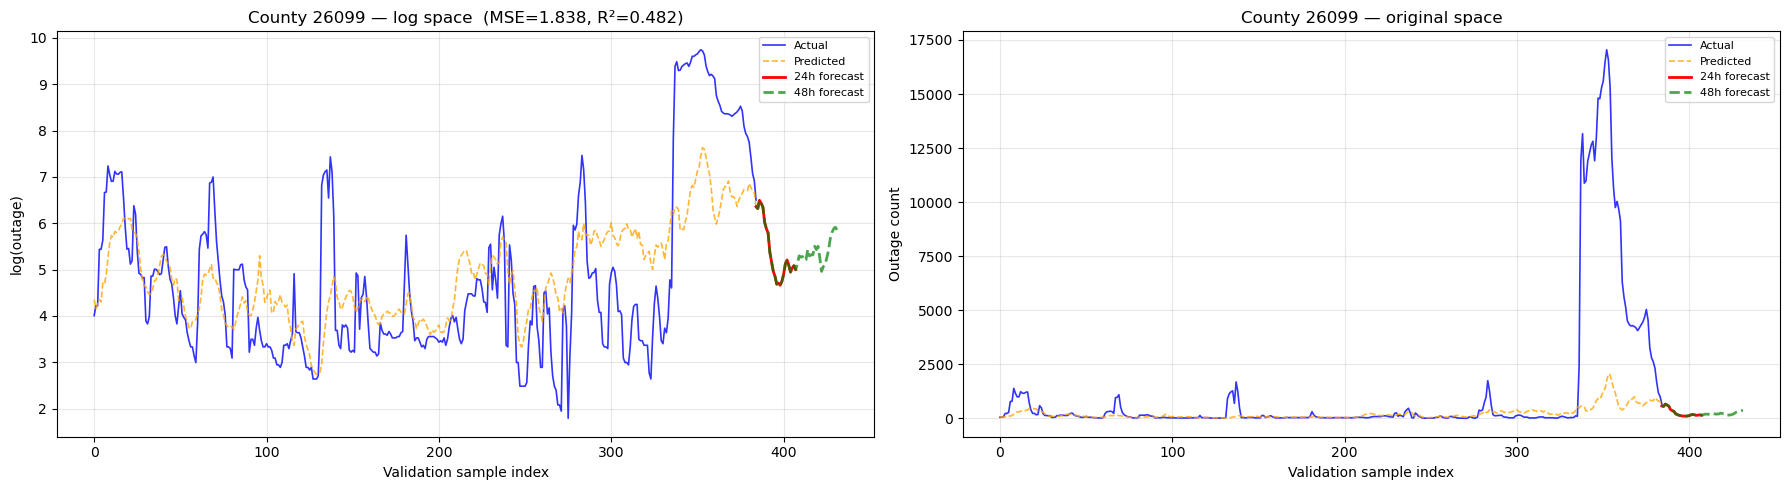

In [70]:
# Visualization for county 26099
county = '26099'
if county in all_results:
    res = all_results[county]
    m = res['metrics']
    n_val = res['preds_log'].shape[0]

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    ax = axes[0]
    ax.plot(res['actuals_log'][:, 0], color='blue', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(res['preds_log'][:, 0], color='orange', linewidth=1.2, linestyle='--', label='Predicted', alpha=0.8)
    last_idx = n_val - 1
    ax.plot(range(last_idx, last_idx + 24), res['preds_log'][-1, :24],
            color='red', linewidth=2, label='24h forecast')
    ax.plot(range(last_idx, last_idx + 48), res['preds_log'][-1, :48],
            color='green', linewidth=2, linestyle='--', label='48h forecast', alpha=0.7)
    ax.set_title(f'County {county} \u2014 log space  (MSE={m["MSE"]:.3f}, R\u00b2={m["R2"]:.3f})')
    ax.set_xlabel('Validation sample index')
    ax.set_ylabel('log(outage)')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(res['actuals'][:, 0], color='blue', linewidth=1.2, label='Actual', alpha=0.8)
    ax.plot(res['preds'][:, 0], color='orange', linewidth=1.2, linestyle='--', label='Predicted', alpha=0.8)
    ax.plot(range(last_idx, last_idx + 24), res['preds'][-1, :24],
            color='red', linewidth=2, label='24h forecast')
    ax.plot(range(last_idx, last_idx + 48), res['preds'][-1, :48],
            color='green', linewidth=2, linestyle='--', label='48h forecast', alpha=0.7)
    ax.set_title(f'County {county} \u2014 original space')
    ax.set_xlabel('Validation sample index')
    ax.set_ylabel('Outage count')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print(f'County {county} not found in results.')

## 8. RMSE Across All Counties

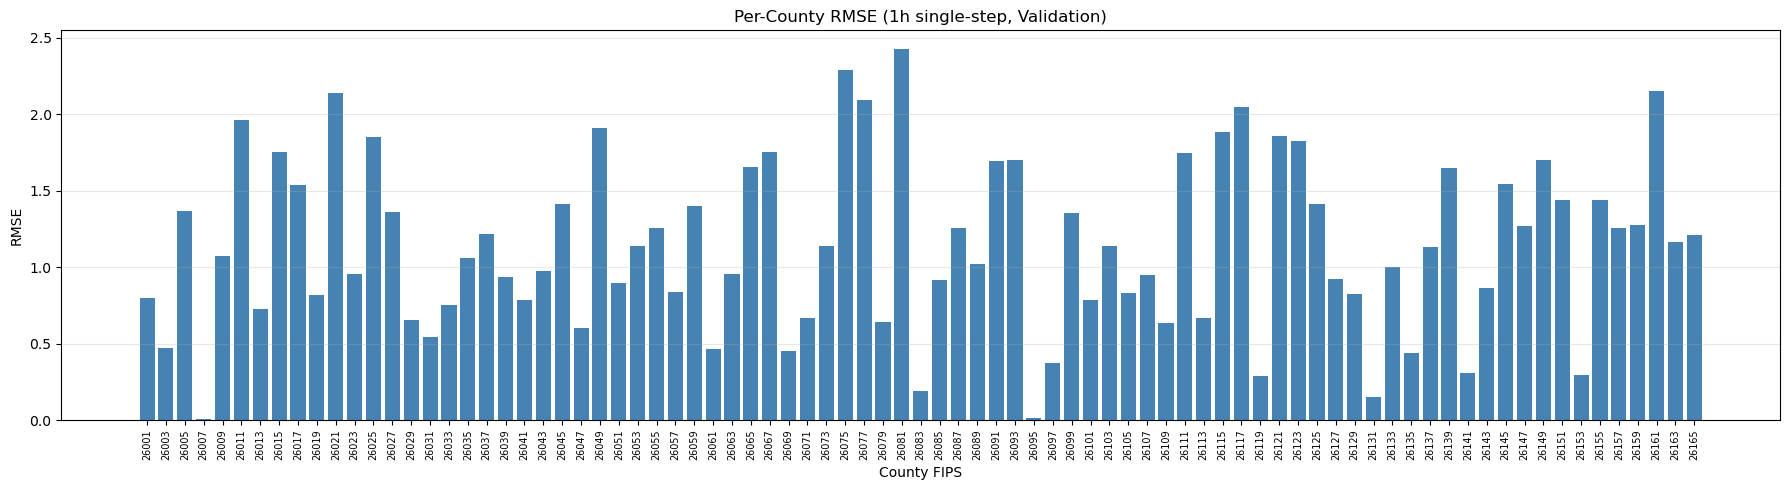

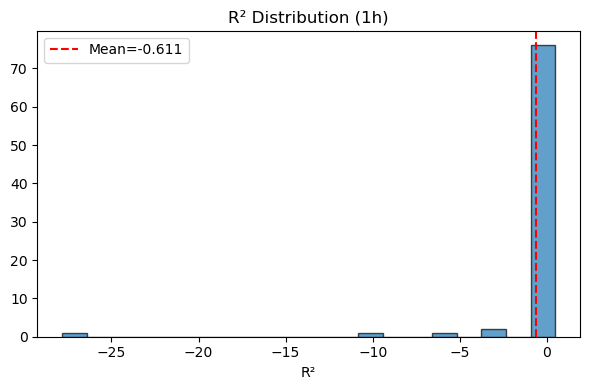

In [67]:
counties_sorted = sorted(all_results.keys())
rmse_vals = [all_results[c]['metrics']['RMSE'] for c in counties_sorted]

fig, ax = plt.subplots(figsize=(18, 5))
x = np.arange(len(counties_sorted))
ax.bar(x, rmse_vals, color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(counties_sorted, rotation=90, fontsize=7)
ax.set_xlabel('County FIPS')
ax.set_ylabel('RMSE')
ax.set_title('Per-County RMSE (1h single-step, Validation)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# R\u00b2 distribution
r2_vals = [all_results[c]['metrics']['R2'] for c in counties_sorted]
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(r2_vals, bins=20, edgecolor='black', alpha=0.7)
ax.set_title('R\u00b2 Distribution (1h)')
ax.set_xlabel('R\u00b2')
ax.axvline(np.nanmean(r2_vals), color='r', linestyle='--',
            label=f'Mean={np.nanmean(r2_vals):.3f}')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Export Predictions

In [68]:
# Export metrics (single sheet, same format as LSTM_metrics.xlsx)
rows = []
for county in sorted(all_results.keys()):
    m = all_results[county]['metrics']
    rows.append({
        'Sheet': county,
        'MSE': round(m['MSE'], 4),
        'MAE': round(m['MAE'], 4),
        'RMSE': round(m['RMSE'], 4),
        'R2': round(m['R2'], 4),
        'window_size': WINDOW_SIZE,
        'd_model': D_MODEL,
        'nhead': NHEAD,
        'num_layers': NUM_LAYERS,
        'dim_ff': DIM_FF,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'lr': LR,
    })
pd.DataFrame(rows).to_excel('transformer_metrics.xlsx', index=False)

print("Saved: transformer_metrics.xlsx")

Saved: transformer_metrics.xlsx


## 10. Generate Submission Files

In [71]:
# ── Generate submission files in required format ──
# Load templates
sub_24h = pd.read_csv('submission_template_24h.csv')
sub_48h = pd.read_csv('submission_template_48h.csv')

# For each county, use the trained model to predict
# Input: last WINDOW_SIZE hours of features from the full dataset
# Output: next 24h / 48h of outage predictions

for county in county_names:
    if county not in all_results:
        # County was skipped — fill with 0
        loc = int(county)
        sub_24h.loc[sub_24h['location'] == loc, 'pred'] = 0
        sub_48h.loc[sub_48h['location'] == loc, 'pred'] = 0
        continue

    res = all_results[county]
    # Use the last prediction window's 48h forecast (in log space)
    # preds_log shape: (N, 48) — take the last window
    forecast_log = res['preds_log'][-1]     # (48,) in log space
    forecast_orig = np.expm1(np.clip(forecast_log, 0, 20))  # convert to outage counts
    forecast_orig = np.maximum(forecast_orig, 0)  # ensure non-negative

    loc = int(county)
    mask_24 = sub_24h['location'] == loc
    mask_48 = sub_48h['location'] == loc

    sub_24h.loc[mask_24, 'pred'] = forecast_orig[:24]
    sub_48h.loc[mask_48, 'pred'] = forecast_orig[:48]

# Save
sub_24h.to_csv('transformer_pred_24h.csv', index=False)
sub_48h.to_csv('transformer_pred_48h.csv', index=False)

print(f'Saved: transformer_pred_24h.csv ({len(sub_24h)} rows)')
print(f'Saved: transformer_pred_48h.csv ({len(sub_48h)} rows)')
print(f'\nSample (24h, county 26001):')
print(sub_24h[sub_24h['location'] == 26001].head())

Saved: transformer_pred_24h.csv (1992 rows)
Saved: transformer_pred_48h.csv (3984 rows)

Sample (24h, county 26001):
      timestamp  location      pred
0  6/30/23 1:00     26001  0.083196
1  6/30/23 2:00     26001  0.175707
2  6/30/23 3:00     26001  0.170288
3  6/30/23 4:00     26001  0.179984
4  6/30/23 5:00     26001  0.142974
